# Figure variants — SHAMe & CV-mean contours

Contour plots in $(\Omega_\mathrm{c},\,\sigma_8,\,\sigma_8 b_1)$ for the fiducial statistic combinations **plus** $P_\mathrm{gm}$-only and $B_\mathrm{ggg}$-only inference.

Statistic order: $P_{gg}$; $P_{gg}+P_{gm}$; $P_{gg}+B_{ggg}$; $P_{gg}+B_{ggg}+P_{gm}$; $P_{gm}$ (navy); $B_{ggg}$ (dark green).

Test sets: fixed-cosmo **CV-mean** and **SHAMe** OOD mocks (all three number densities).

In [1]:
import sys
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
from matplotlib import pyplot as plt

import paths
import plotter
import data_loader
import generate_params as genp
import utils_plot

%load_ext autoreload
%autoreload 2

In [2]:
# --- Fiducial config ---
bx = 32
n_train = 10000
TAG_INF_BEST_SUFFIX = "_best-rand30"

data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"
tag_reparam = "_rp"

STATISTICS_ARR_FID = [
    ["pk"],
    ["pk", "pgm"],
    ["pk", "bispec"],
    ["pk", "bispec", "pgm"],
    ["pgm"],
    ["bispec"],
]
TAGS_MASK_FID = [
    "",
    "_kpgm0.25",
    "_kb0.25",
    "_kb0.25_kpgm0.25",
    "_kpgm0.25",
    "_kb0.25",
]
# pk, pk+pgm, pk+bispec, pk+bispec+pgm, pgm-only (navy), bispec-only (dark green)
COLORS_FID = ["#79D0EC", "#6BB756", "#9D86E0", "#B32168", "#001f3f", "#006400"]

STAT_LABELS_SHORT = {
    "pk": r"$P_\mathrm{gg}$",
    "bispec": r"$B_\mathrm{ggg}$",
    "pgm": r"$P_\mathrm{gm}$",
}


def get_stat_label_short(statistics):
    order = {"pk": 0, "pgm": 1, "bispec": 2}
    stats = sorted(statistics, key=lambda s: order.get(s, 99))
    return " + ".join(STAT_LABELS_SHORT[s] for s in stats)


TAG_PARAMS_TEST_FIXED = "_shame_p0_n1000"
TAG_BIASPARAMS_TEST_FIXED = "_biasshame_noisebest_p0_n1"
TAG_NOISE_TEST_FIXED = "_noise_unit_shame_p0_n1000"
TAG_DATAGEN_TEST_MEAN = "_mean"

DATA_MODE_TEST_SHAME = "shame"
TAG_MOCK_SHAME = "_nbar0.00022"

param_names_key, param_names_key_rp = utils_plot.get_param_names_key()
PARAM_NAMES_ZOOM = list(param_names_key)
idx_obs = 0

extents = {**genp.get_bounds("cosmo"), **genp.get_bounds("bias")}
extents_contours = extents.copy()
extents_contours["b1"] = [0.0, 1.0]


def theta_show_sigma8xb1(theta_show):
    i_s8 = PARAM_NAMES_ZOOM.index("sigma8_cold")
    i_b1 = PARAM_NAMES_ZOOM.index("b1")
    return np.array(
        [
            theta_show[PARAM_NAMES_ZOOM.index("omega_cold")],
            theta_show[i_s8],
            theta_show[i_s8] * theta_show[i_b1],
        ],
        dtype=float,
    )


def extents_sigma8xb1(theta_show, extents_phys=None):
    if extents_phys is None:
        extents_phys = extents_contours
    i_s8 = PARAM_NAMES_ZOOM.index("sigma8_cold")
    extents_rp = {k: v for k, v in extents_phys.items() if k != "b1"}
    extents_rp["sigma8_cold_x_b1"] = [
        extents_phys["b1"][0] * theta_show[i_s8],
        extents_phys["b1"][1] * theta_show[i_s8],
    ]
    return extents_rp


FIGSIZE_CORNER = (5.5, 5.5)
FONTSIZE_LEGEND = 10
LOC_LEGEND = (1.02, 0.98)
dir_sbi = paths.DIR_RESULTS / "results_sbi"

FIG_DIR = REPO_ROOT / "figures" / "2026-09-02_figure_variants"
OVERWRITE_FIGURES = True
FIG_EXT = "png"


def save_figure(fig, name, ext=FIG_EXT):
    filename = f"{name}.{ext}"
    path = FIG_DIR / filename
    if path.exists() and not OVERWRITE_FIGURES:
        print(f"Skipping save (exists, overwrite=False): {filename}")
        return
    fig.canvas.draw_idle()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, bbox_inches="tight", facecolor="white", edgecolor="none")
    print(f"Saved: {path}")


def setup_fiducial_inference():
    tags_inf, labels, colors, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=STATISTICS_ARR_FID,
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=TAGS_MASK_FID,
    )
    tags_inf = [t + TAG_INF_BEST_SUFFIX for t in tags_inf]
    labels = [get_stat_label_short(s) for s in STATISTICS_ARR_FID]
    return tags_inf, labels, list(COLORS_FID)


def sample_fn(tag_inf, tag_test):
    return dir_sbi / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"


def samples_exist(tags_inf, tags_test):
    return [sample_fn(ti, tt).exists() for ti, tt in zip(tags_inf, tags_test)]


def setup_fixed_mean_test():
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
        tag_stats_arr=tag_stats_arr,
        tag_noise_test=TAG_NOISE_TEST_FIXED,
        tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
        tags_mask_test=TAGS_MASK_FID,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta = data_loader.load_theta_test(
        TAG_PARAMS_TEST_FIXED,
        TAG_BIASPARAMS_TEST_FIXED,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
    )
    theta_obs = theta[idx_obs] if theta.ndim == 2 else theta
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, theta_obs, theta_obs[idxs_zoom], param_vary


NBAR_TAGS_SHAME = ["_nbar0.00011", "_nbar0.00022", "_nbar0.00054"]
NBAR_LABELS_SHAME = {
    "_nbar0.00011": r"$\bar{n}=1.1\times10^{-4}$",
    "_nbar0.00022": r"$\bar{n}=2.2\times10^{-4}$",
    "_nbar0.00054": r"$\bar{n}=5.4\times10^{-4}$",
}


def setup_shame_test(tag_mock=TAG_MOCK_SHAME):
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
    tags_test = utils_plot.setup_shame_mock_test_tags(
        tag_stats_arr=tag_stats_arr,
        data_mode_test=DATA_MODE_TEST_SHAME,
        tag_mock=tag_mock,
        tags_mask=TAGS_MASK_FID,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta_dict = data_loader.load_params_ood(DATA_MODE_TEST_SHAME, tag_mock)
    theta_obs_full = np.array([theta_dict.get(pn, np.nan) for pn in param_vary])
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, param_vary, theta_obs_full[idxs_zoom]


def plot_fiducial_contours(
    tags_inf, labels, colors, tags_test, keep, theta_show, *,
    extents=None, add_truth=True, save_name=None,
    param_names=None, unreparameterize=True,
    fontsize_legend=FONTSIZE_LEGEND,
    legend_location=None,
    legend_loc=None,
    loc_legend=LOC_LEGEND,
):
    idxs = [i for i, k in enumerate(keep) if k]
    if not idxs:
        print("No samples on disk for fiducial contours")
        for i, k in enumerate(keep):
            if not k:
                print(f"  missing: {sample_fn(tags_inf[i], tags_test[i])}")
        return
    fig = plotter.plot_contours_inf(
        param_names=param_names or PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs],
        tags_test=[tags_test[i] for i in idxs],
        colors=[colors[i] for i in idxs],
        labels=[labels[i] for i in idxs],
        title=None,
        extents=extents or extents_contours,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=fontsize_legend,
        legend_location=legend_location,
        legend_loc=legend_loc,
        loc_legend=loc_legend,
        unreparameterize=unreparameterize,
        add_truth=add_truth,
        show=False,
    )
    if save_name is not None and fig is not None:
        save_figure(fig, save_name)
    plt.show()

## CV-mean contours ($\sigma_8 b_1$)

Fixed-cosmo mean data vector (cosmic-variance test set). All six statistic combinations overlaid in the NPE training coordinate $\sigma_8 b_1$.

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2

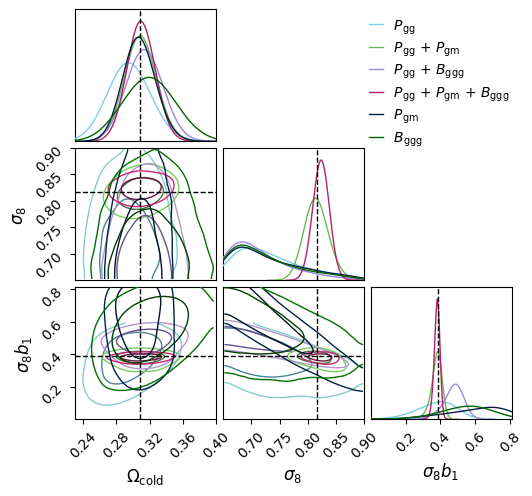

In [3]:
tags_inf, labels, colors, tags_test, keep, _, theta_show_cv, _ = setup_fixed_mean_test()

plot_fiducial_contours(
    tags_inf, labels, colors, tags_test, keep,
    theta_show=theta_show_sigma8xb1(theta_show_cv),
    extents=extents_sigma8xb1(theta_show_cv),
    param_names=list(param_names_key_rp),
    unreparameterize=False,
    save_name="cvmean_contours_sigma8xb1",
)

## SHAMe OOD contours ($\sigma_8 b_1$)

SHAMe out-of-distribution mocks at three number densities. Same six statistic combinations; $P_\mathrm{gm}$-only in **navy** and $B_\mathrm{ggg}$-only in **dark green**.

SHAMe OOD contours: $\bar{n}=1.1\times10^{-4}$ → shame_contours_sigma8xb1_nbar0.00011
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00011_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.25_nbar0.00011_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00011_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_sha

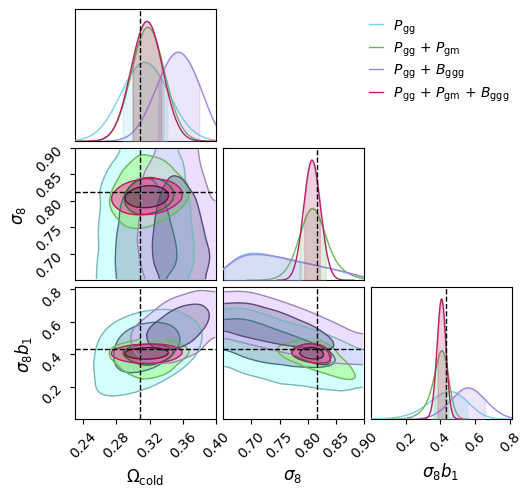

SHAMe OOD contours: $\bar{n}=2.2\times10^{-4}$ → shame_contours_sigma8xb1
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec

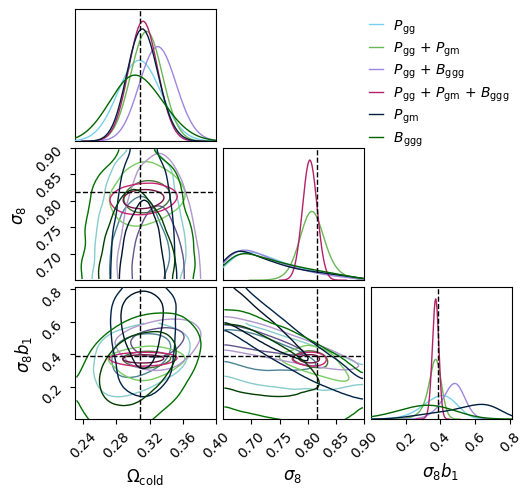

SHAMe OOD contours: $\bar{n}=5.4\times10^{-4}$ → shame_contours_sigma8xb1_nbar0.00054
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00054_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.25_nbar0.00054_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00054_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_sha

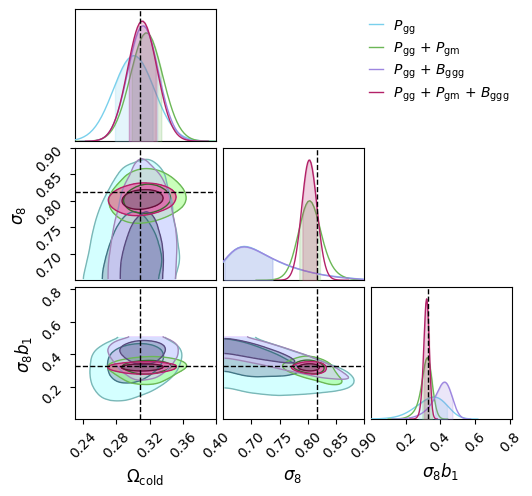

In [4]:
for tag_mock in NBAR_TAGS_SHAME:
    tags_inf, labels, colors, tags_test, keep, _, theta_show_shame = setup_shame_test(
        tag_mock=tag_mock,
    )
    nbar_slug = tag_mock.replace("_nbar", "nbar")
    save_name = (
        "shame_contours_sigma8xb1"
        if tag_mock == TAG_MOCK_SHAME
        else f"shame_contours_sigma8xb1_{nbar_slug}"
    )
    print(f"SHAMe OOD contours: {NBAR_LABELS_SHAME[tag_mock]} → {save_name}")
    plot_fiducial_contours(
        tags_inf, labels, colors, tags_test, keep,
        theta_show=theta_show_sigma8xb1(theta_show_shame),
        extents=extents_sigma8xb1(theta_show_shame),
        param_names=list(param_names_key_rp),
        unreparameterize=False,
        save_name=save_name,
    )

## Fig. 2 variant — training ranges with $-1 < b_2 < 0$

Same layout as Fig. 2 (training-set percentile bands plus SHAMe OOD mocks), but the training bands include only realizations with $0 < b_2 < 1$.

Loaded pk with shape (32,)
Loaded pgm with shape (32,)
Loaded bispec with shape (203,)
Loaded pk with shape (32,)
Loaded pgm with shape (32,)
Loaded bispec with shape (203,)
Loaded pk with shape (32,)
Loaded pgm with shape (32,)
Loaded bispec with shape (203,)
P(k)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000


Found 10000 diff cosmo pks in /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
  kept 797/3200 realizations with -1.0 < b2 < 0.0
P_gm(k)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Found 10000 diff cosmo pgms in /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
  kept 797/3200 realizations with -1.0 < b2 < 0.0
B(k1,k2,k3)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_p5_n10000_biasnoisenest_p9_n32000

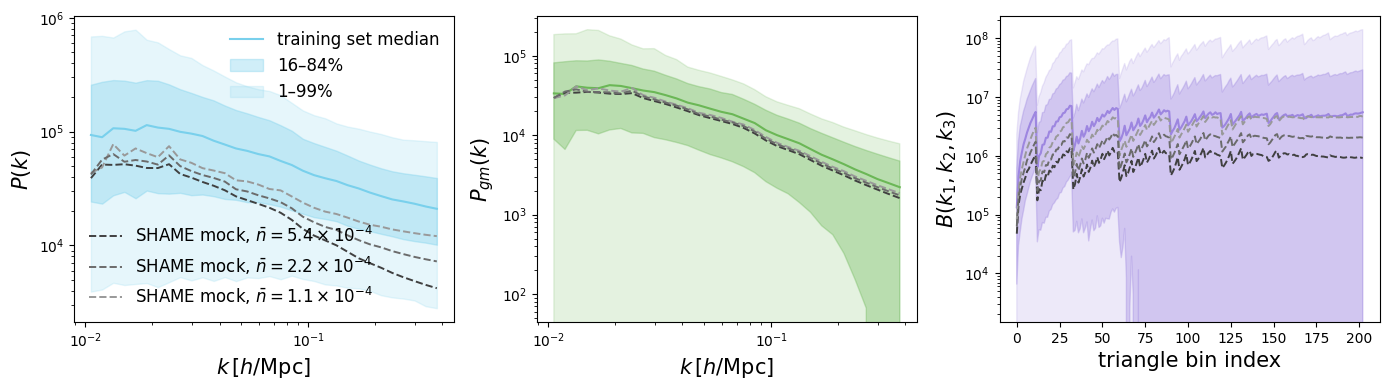

In [3]:
COLOR_STAT = {
    "pk": COLORS_FID[0],
    "pgm": COLORS_FID[1],
    "bispec": COLORS_FID[2],
}
SHAME_LINESTYLE = "--"
SHAME_LINEWIDTH = 1.4
LABELSIZE = 15
LEGENDSIZE = 12
n_cosmo_max_stats = 100

NBAR_TAGS_STATS = ["_nbar0.00054", "_nbar0.00022", "_nbar0.00011"]
NBAR_COLORS_STATS = {
    "_nbar0.00054": "0.25",
    "_nbar0.00022": "0.42",
    "_nbar0.00011": "0.60",
}
NBAR_LABELS_STATS = {
    "_nbar0.00054": r"SHAME mock, $\bar{n}=5.4\times10^{-4}$",
    "_nbar0.00022": r"SHAME mock, $\bar{n}=2.2\times10^{-4}$",
    "_nbar0.00011": r"SHAME mock, $\bar{n}=1.1\times10^{-4}$",
}


def stats_summary(arr):
    return (
        np.nanmedian(arr, axis=0),
        np.nanpercentile(arr, 1, axis=0),
        np.nanpercentile(arr, 16, axis=0),
        np.nanpercentile(arr, 84, axis=0),
        np.nanpercentile(arr, 99, axis=0),
    )


def plot_stat_band(ax, x, median, p1, p16, p84, p99, color, *, with_labels=True):
    lab_med = "training set median" if with_labels else None
    lab_1684 = "16–84%" if with_labels else None
    lab_199 = "1–99%" if with_labels else None
    ax.plot(x, median, color=color, label=lab_med, zorder=3)
    ax.fill_between(x, p16, p84, color=color, alpha=0.35, label=lab_1684, zorder=2)
    ax.fill_between(x, p1, p99, color=color, alpha=0.18, label=lab_199, zorder=1)


def filter_stats_by_b2(stat_arr, idxs_params, biasparams_df, *, b2_lo=0.0, b2_hi=1.0):
    keep = np.array([
        b2_lo < biasparams_df.loc[idx_bias, "b2"] < b2_hi
        for _, idx_bias, _ in idxs_params
    ])
    print(f"  kept {keep.sum()}/{len(keep)} realizations with {b2_lo} < b2 < {b2_hi}")
    return stat_arr[keep]


def load_training_stat_filtered(statistic, *, b2_lo=-1.0, b2_hi=0.0):
    k, stats, _, idxs_params = data_loader.load_data_muchisimocks(
        statistic,
        TAG_PARAMS_TRAIN,
        TAG_BIASPARAMS_TRAIN,
        tag_noise=TAG_NOISE_TRAIN,
        bx=bx,
        n_cosmo_max=n_cosmo_max_stats,
    )
    biasparams_df, _ = data_loader.load_bias_params(TAG_BIASPARAMS_TRAIN, bx=bx)
    stats_f = filter_stats_by_b2(stats, idxs_params, biasparams_df, b2_lo=b2_lo, b2_hi=b2_hi)
    return k, stats_f


shame_stats = {}
for tag_mock in NBAR_TAGS_STATS:
    k_pk_s, y_pk_s, _ = data_loader.load_data_shame("pk", tag_mock)
    k_pgm_s, y_pgm_s, _ = data_loader.load_data_shame("pgm", tag_mock)
    _, y_b_s, _ = data_loader.load_data_shame("bispec", tag_mock)
    shame_stats[tag_mock] = {
        "pk": (k_pk_s, y_pk_s),
        "pgm": (k_pgm_s, y_pgm_s),
        "bispec": (np.arange(len(y_b_s)), y_b_s),
    }


def plot_shame_nbars(ax, statistic, *, with_labels=False):
    for tag_mock in NBAR_TAGS_STATS:
        x, y = shame_stats[tag_mock][statistic]
        ax.plot(
            x, y,
            color=NBAR_COLORS_STATS[tag_mock],
            linestyle=SHAME_LINESTYLE,
            linewidth=SHAME_LINEWIDTH,
            label=NBAR_LABELS_STATS[tag_mock] if with_labels else None,
            zorder=5 if tag_mock == TAG_MOCK_SHAME else 4,
        )


def add_split_legends(ax):
    h_all, l_all = ax.get_legend_handles_labels()
    train_keys = {"training set median", "16–84%", "1–99%"}
    h_train, l_train, h_shame, l_shame = [], [], [], []
    for h, lab in zip(h_all, l_all):
        if lab in train_keys:
            h_train.append(h)
            l_train.append(lab)
        else:
            h_shame.append(h)
            l_shame.append(lab)
    leg_train = ax.legend(
        h_train, l_train, loc="upper right", fontsize=LEGENDSIZE,
        frameon=False, labelcolor="black",
    )
    ax.add_artist(leg_train)
    ax.legend(
        h_shame, l_shame, loc="lower left", fontsize=LEGENDSIZE,
        frameon=False, labelcolor="black",
    )


fig, axes = plt.subplots(1, 3, figsize=(14, 4))

print("P(k)")
k_pk, pks = load_training_stat_filtered("pk")
median_pk, p1_pk, p16_pk, p84_pk, p99_pk = stats_summary(pks)
plot_stat_band(axes[0], k_pk, median_pk, p1_pk, p16_pk, p84_pk, p99_pk, COLOR_STAT["pk"], with_labels=True)
plot_shame_nbars(axes[0], "pk", with_labels=True)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel(r"$k\,[h/\mathrm{Mpc}]$", fontsize=LABELSIZE)
axes[0].set_ylabel(r"$P(k)$", fontsize=LABELSIZE)
add_split_legends(axes[0])

print("P_gm(k)")
k_pgm, pgms = load_training_stat_filtered("pgm")
median_pgm, p1_pgm, p16_pgm, p84_pgm, p99_pgm = stats_summary(pgms)
plot_stat_band(axes[1], k_pgm, median_pgm, p1_pgm, p16_pgm, p84_pgm, p99_pgm, COLOR_STAT["pgm"], with_labels=False)
plot_shame_nbars(axes[1], "pgm", with_labels=False)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel(r"$k\,[h/\mathrm{Mpc}]$", fontsize=LABELSIZE)
axes[1].set_ylabel(r"$P_{gm}(k)$", fontsize=LABELSIZE)

print("B(k1,k2,k3)")
_, bispecs = load_training_stat_filtered("bispec")
median_b, p1_b, p16_b, p84_b, p99_b = stats_summary(bispecs)
x_b = np.arange(len(median_b))
plot_stat_band(axes[2], x_b, median_b, p1_b, p16_b, p84_b, p99_b, COLOR_STAT["bispec"], with_labels=False)
plot_shame_nbars(axes[2], "bispec", with_labels=False)
axes[2].set_yscale("log")
axes[2].set_xlabel("triangle bin index", fontsize=LABELSIZE)
axes[2].set_ylabel(r"$B(k_1,k_2,k_3)$", fontsize=LABELSIZE)

plt.tight_layout()
save_figure(fig, "fig2_statistics_ranges_b2_0_1")
plt.show()